In [2]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib as mpl
from read_alf import Alf
from matplotlib.legend_handler import HandlerTuple

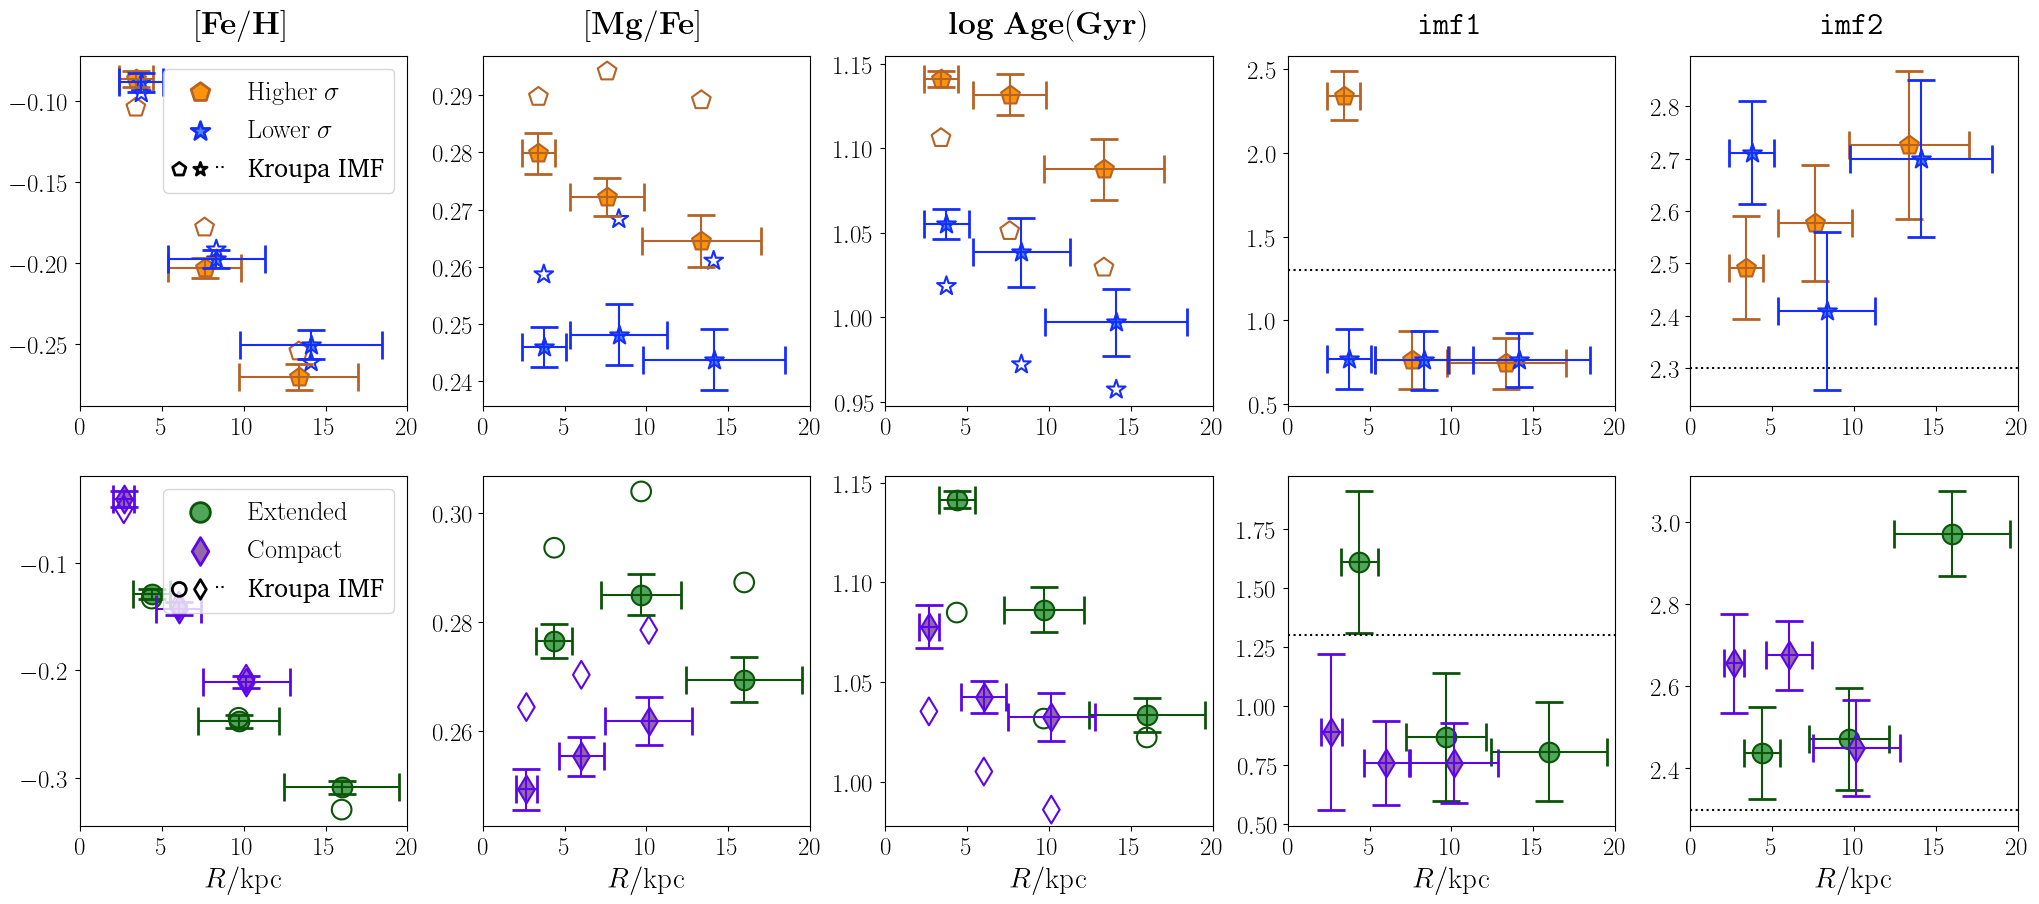

In [5]:
comp_path = '../data/alf/full/'
path = '../data/alf/simple/'

parameters = fits.open('../data/parameters_reff2_2.fits')
split = fits.open('../data/sample_split_outliers_total2.fits')
rnames = ['rin_median(kpc)', 'rmid_median(kpc)', 'rout_median(kpc)']
split_type = ['m20kpc_v_sigmacen', 'm10kpc_v_m20kpc']
label_names = ['high', 'low']
radius_name = ['in', 'mid', 'out']
labels = ['High', 'Low']
sga_mass = fits.getdata('../data/sga_mass_new_28mag2.fits',1)
normalize = mcolors.Normalize(vmin=-1.3, vmax=0.3)
colormap = mpl.cm.PRGn
color_low = colormap(normalize(-1))
color_high = colormap(normalize(0))
keywords = np.array(['Fe/H', 'Mg/Fe', 'Mg', 'Age', 'IMF1', 'IMF2'])
titles = np.array(['Fe/H', 'Mg/Fe', 'Age', 'IMF1', 'IMF2'])
titles_full = [r'$\mathbf{[Fe/H]}$', r'$\mathbf{[Mg/Fe]}$', r'$\mathbf{log\ Age(Gyr)}$',
               r'$\texttt{imf1}$', r'$\texttt{imf2}$']
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Charter",
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "axes.labelsize": 20,
    "axes.labelweight": "bold"
    })
fig, ax = plt.subplots(2, len(titles), figsize=(5 * len(titles), 10), clear=True)

for split_num in range(2):
    colors = [color_high, color_low]
    edgecolors = ['xkcd:forest', 'xkcd:blue violet']
    shapes = ['o', 'd']
    sample_labels = [r'$\mathrm{Extended}$', r'$\mathrm{Compact}$']
    xmin, xmax = 10, 10

    if split_num == 0:
        colors = ['xkcd:tangerine', 'xkcd:dark sky blue']
        edgecolors = ['xkcd:copper', 'xkcd:vivid blue']
        sample_labels = [r'$\mathrm{Higher\ \sigma}$', r'$\mathrm{Lower\ \sigma}$']
        shapes = ['p', '*']

    ele_abundances = ['Mg']
    params = ['Mg']

    data = {}
    err = {}

    for i in range(2):
        for name in keywords:
            data[name] = [[[], [], []], [[], [], []]]
            err[name] = [[[], [], []], [[], [], []]]

    for i in range(2):
        for j in range(3):
            myalf = Alf(
                path + split_type[split_num] + '/' + label_names[i] + '_' + split_type[split_num] + '_'
                + radius_name[j])
            myalf.get_total_met()
            myalf.abundance_correct()
            data['Fe/H'][i][j].append(myalf.tmet['cl50'])
            err['Fe/H'][i][j].append(myalf.tmet['std'])
            feh = np.where(myalf.labels == 'FeH')
            zh = np.where(myalf.labels == 'zH')
            mg = np.where(myalf.labels == 'Mg')

            # data['logAge'][i][j].append(myalf.results['logage'][0])
            # err['logAge'][i][j].append(myalf.results['logage'][2])
            for name in params:
                para_mcmc = myalf.mcmc[:, feh].flatten() + myalf.mcmc[:,
                                                           zh].flatten() + myalf.get_corrected_abundance_posterior(name)
                para_tmp = myalf.get_cls(para_mcmc)
                data[name][i][j].append(para_tmp['cl50'])
                err[name][i][j].append(para_tmp['std'])

            for name in ele_abundances:
                data[name + '/Fe'][i][j].append(myalf.xFe[name]['cl50'])
                err[name + '/Fe'][i][j].append(myalf.xFe[name]['std'])
            data['IMF1'][i][j].append(myalf.results['IMF1'][5])
            err['IMF1'][i][j].append(myalf.results['IMF1'][2])
            data['IMF2'][i][j].append(myalf.results['IMF2'][5])
            err['IMF2'][i][j].append(myalf.results['IMF2'][2])
            data['Age'][i][j].append(myalf.results['logage'][0])
            err['Age'][i][j].append(myalf.results['logage'][2])

    comp_data = {}
    comp_err = {}
    for i in range(2):
        for name in keywords:
            comp_data[name] = [[[], [], []], [[], [], []]]
            comp_err[name] = [[[], [], []], [[], [], []]]

    for i in range(2):
        for j in range(3):
            comp_alf = Alf(
                comp_path + split_type[split_num] + '/' + label_names[i] + '_' + split_type[split_num] + '_' +
                radius_name[j] + '_full')
            comp_alf.get_total_met()
            comp_alf.abundance_correct()
            comp_data['Fe/H'][i][j].append(comp_alf.tmet['cl50'])
            comp_err['Fe/H'][i][j].append(comp_alf.tmet['std'])
            comp_data['Age'][i][j].append(comp_alf.results['logage'][0])
            comp_err['Age'][i][j].append(comp_alf.results['logage'][2])

            comp_data['IMF1'][i][j].append(comp_alf.results['IMF1'][5])
            comp_err['IMF1'][i][j].append(comp_alf.results['IMF1'][2])
            comp_data['IMF2'][i][j].append(comp_alf.results['IMF2'][5])
            comp_err['IMF2'][i][j].append(comp_alf.results['IMF2'][2])
            # comp_data['IMF3'][i][j].append(comp_alf.results['IMF3'][5])
            # comp_err['IMF3'][i][j].append(comp_alf.results['IMF3'][2])
            feh = np.where(comp_alf.labels == 'FeH')
            zh = np.where(comp_alf.labels == 'zH')
            mg = np.where(comp_alf.labels == 'Mg')
            for name in params:
                para_mcmc = comp_alf.mcmc[:, feh].flatten() + comp_alf.mcmc[:,
                                                              zh].flatten() + myalf.get_corrected_abundance_posterior(
                    name)
                para_tmp = comp_alf.get_cls(para_mcmc)
                comp_data[name][i][j].append(para_tmp['cl50'])
                comp_err[name][i][j].append(para_tmp['std'])

            for name in ele_abundances:
                comp_data[name + '/Fe'][i][j].append(comp_alf.xFe[name]['cl50'])
                comp_err[name + '/Fe'][i][j].append(comp_alf.xFe[name]['std'])
    for idx_cal, name in enumerate(titles):
        ax[1][idx_cal].set_xlabel(r'$R\mathrm{/kpc}$', fontsize=21)
        for i in range(2):
            mask = split[1].data[split_type[split_num]] % 2 == i
            ifus, idx, _ = np.intersect1d(parameters[1].data['plateifu'], split[1].data['plateifu'][mask],
                                          return_indices=True)
            _, idx_re, idx0 = np.intersect1d(sga_mass['plateifu'], ifus, return_indices=True)
            re = sga_mass['Re_kpc'][idx_re]
            dx_tmp, dy_tmp = [], []
            for j in range(3):
                # r_tmp=0.5 * j + i * 0.04
                r_tmp = np.nanmedian(parameters[1].data[rnames[j]][idx])
                re_tmp = np.nanmedian(parameters[1].data[rnames[j]][idx] / re)
                if r_tmp < xmin-np.nanstd(parameters[1].data[rnames[j]][idx]):
                    xmin = np.copy(r_tmp-np.nanstd(parameters[1].data[rnames[j]][idx]))
                if r_tmp > xmax+np.nanstd(parameters[1].data[rnames[j]][idx]):
                    xmax = np.copy(r_tmp+np.nanstd(parameters[1].data[rnames[j]][idx]))

                ax[split_num][idx_cal].errorbar([r_tmp], [comp_data[name][i][j]],
                                                xerr=[np.nanstd(parameters[1].data[rnames[j]][idx])],
                                                yerr=[comp_err[name][i][j]],
                                                ecolor=edgecolors[i], linewidth=1.5, capsize=10, capthick=2,
                                                linestyle=None,
                                                alpha=1)

                ax[split_num][idx_cal].scatter([r_tmp], [comp_data[name][i][j]], s=200,
                                               edgecolors=edgecolors[i], facecolors=colors[i], linewidths=1.5,
                                               marker=shapes[i],
                                               alpha=1)
                ax[split_num][idx_cal].set_xlim([0,20])
                if idx_cal < len(titles) - 2:
                    # ax[idx_cal].errorbar([r_tmp], [data[name][i][j]], yerr=[err[name][i][j]],
                    #                      ecolor=colors[i], linewidth=3, capsize=10, capthick=4, linestyle=None,
                    #                      alpha=1)

                    ax[split_num][idx_cal].scatter([r_tmp], [data[name][i][j]], s=200,
                                                   edgecolors=edgecolors[i], facecolors='None', linewidths=1.5,
                                                   marker=shapes[i],
                                                   alpha=1)
                if split_num == 0:
                    # ax[split_num-2][idx_cal].xaxis.set_visible(False)
                    ax[split_num][idx_cal].set_title(titles_full[idx_cal], x=.5, y=1.04, fontsize=23)
    xmin,xmax=0,20
    l1, = ax[split_num][-2].plot(np.linspace(xmin, xmax), np.full(50, 1.3), 'k:', lw=1.5)
    ax[split_num][-1].plot(np.linspace(xmin, xmax), np.full(50, 2.3), 'k:', lw=1.5)
    # ax[split_num][4].plot(np.linspace(xmin, xmax), np.full(50, 0.08), 'k:', lw=1.5)

    s1 = ax[split_num][1].scatter([], [], s=200, marker=shapes[0], facecolor=colors[0], edgecolor=edgecolors[0],
                                  label=sample_labels[0], lw=2)
    s2 = ax[split_num][1].scatter([], [], s=200, marker=shapes[1], facecolor=colors[1], edgecolor=edgecolors[1],
                                  label=sample_labels[1], lw=2)
    s3 = ax[split_num][1].scatter([], [], s=100, marker=shapes[0], facecolor='None', edgecolor='black',
                                  label='Kroupa IMF',
                                  lw=2)
    s4 = ax[split_num][1].scatter([], [], s=100, marker=shapes[1], facecolor='None', edgecolor='black',
                                  lw=2)

    handles = [s1, s2, (s3, s4, l1)]
    _, labels = ax[split_num][1].get_legend_handles_labels()

    ax[split_num][0].legend(handles=handles, labels=labels, fontsize=19,
                            handler_map={tuple: HandlerTuple(None)})
fig.subplots_adjust(wspace=0.23)